# Business Problem

A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delivery, for products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.

# Desired Outcome:

The goal is to analyze delivery operations, identify bottlenecks, and built a predictive system to reduce delays, optimize shipping decision, and improve overall profitability and efficiency.

In [64]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm 
from warnings import filterwarnings
filterwarnings('ignore')

In [66]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors


In [67]:
df = pd.read_csv('SupplyChain_dataset.csv', encoding = 'latin-1')

In [4]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [6]:
df.shape

(180519, 53)

In [7]:
df.describe

<bound method NDFrame.describe of             Type  Days for shipping (real)  Days for shipment (scheduled)  \
0          DEBIT                         3                              4   
1       TRANSFER                         5                              4   
2           CASH                         4                              4   
3          DEBIT                         3                              4   
4        PAYMENT                         2                              4   
...          ...                       ...                            ...   
180514      CASH                         4                              4   
180515     DEBIT                         3                              2   
180516  TRANSFER                         5                              4   
180517   PAYMENT                         3                              4   
180518   PAYMENT                         4                              4   

        Benefit per order  Sales per cust

In [68]:
# Exploratory Data Analysis (EDA)

print('rows, cols:', df.shape)
print('\columns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending = False).head(20))

rows, cols: (180519, 53)
\columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [9]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")


In [10]:
(df['benefit_per_order'] == df['order_profit_per_order']).value_counts()

True    180519
Name: count, dtype: int64

In [11]:
df['product_status'].value_counts()

product_status
0    180519
Name: count, dtype: int64

In [12]:
# Data Cleaning

columns_to_drop = [
    'product_description',
    'product_image',
    'customer_email',
    'customer_password',
    'customer_fname',
    'customer_lname',
    'customer_street',
    'customer_zipcode',
    'order_zipcode',
    'latitude',
    'longitude',
    'market',
    'order_city',
    'order_country',
    'order_state',
    'order_customer_id',
    'order_item_cardprod_id',
    'order_item_id',
    'order_item_discount',
    'order_item_discount_rate',
    'order_item_product_price',
    'order_item_quantity',
    'order_item_total',
    'category_id',
    'department_id',
    'order_id',
    'customer_id',
    'product_card_id',
    'product_category_id',
    'benefit_per_order',
    'product_status',
    'customer_city',
    'customer_state']

#Dropping columns that are either fully missing, redunant, or have only one value (and thus no variance)
df = df.drop(columns = columns_to_drop)

In [13]:
df.columns

Index(['type', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)',
       'sales_per_customer', 'delivery_status', 'late_delivery_risk',
       'category_name', 'customer_country', 'customer_segment',
       'department_name', 'order_date_(dateorders)', 'order_item_profit_ratio',
       'sales', 'order_profit_per_order', 'order_region', 'order_status',
       'product_name', 'product_price', 'shipping_date_(dateorders)',
       'shipping_mode'],
      dtype='object')

In [14]:
df.shape

(180519, 20)

In [15]:
print(df.isnull().sum().sort_values(ascending=False))

type                             0
days_for_shipping_(real)         0
shipping_date_(dateorders)       0
product_price                    0
product_name                     0
order_status                     0
order_region                     0
order_profit_per_order           0
sales                            0
order_item_profit_ratio          0
order_date_(dateorders)          0
department_name                  0
customer_segment                 0
customer_country                 0
category_name                    0
late_delivery_risk               0
delivery_status                  0
sales_per_customer               0
days_for_shipment_(scheduled)    0
shipping_mode                    0
dtype: int64


In [16]:
# removing canceled order since they are not relevant for delivery time analysis and may have diffreent patterns than completed orders
before_rows = len(df)
before_rows
df = df[df['delivery_status'] != 'Shipping canceled']

after_rows = len(df)
after_rows
print('removed_orders:', before_rows - after_rows)



removed_orders: 7754


In [17]:
before_rows

180519

In [18]:
after_rows

172765

In [19]:
print(df['delivery_status'].value_counts())

delivery_status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64


In [20]:
#standard date conversion
for c in ['order_date_(dateorders)', 'shipping_date_(dateorders)']:
    df[c] = pd.to_datetime(df[c], errors = 'coerce', dayfirst = False)

print('rows, cols:', df.shape)
print('\nMissing value (top 5):')
print(df.isna().sum().sort_values(ascending = False).head(5))

rows, cols: (172765, 20)

Missing value (top 5):
type                          0
days_for_shipping_(real)      0
shipping_date_(dateorders)    0
product_price                 0
product_name                  0
dtype: int64


In [21]:
df.head()

,type,days_for_shipping_(real),days_for_shipment_(scheduled),sales_per_customer,delivery_status,late_delivery_risk,category_name,customer_country,customer_segment,department_name,order_date_(dateorders),order_item_profit_ratio,sales,order_profit_per_order,order_region,order_status,product_name,product_price,shipping_date_(dateorders),shipping_mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [22]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col}, value counts:')
        print(df[col].value_counts())


type, value counts:
type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

days_for_shipping_(real), value counts:
days_for_shipping_(real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

days_for_shipment_(scheduled), value counts:
days_for_shipment_(scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

delivery_status, value counts:
delivery_status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

late_delivery_risk, value counts:
late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

customer_country, value counts:
customer_country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

customer_segment, value counts:
customer_segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

order_status, value counts:
order_status
CO

In [23]:
df['order_processing_time'] = (df['shipping_date_(dateorders)'] - df['order_date_(dateorders)']).dt.days
df['delay'] = df['order_processing_time'] - df['days_for_shipment_(scheduled)']
df['is_delayed'] = df['delay'] > 0
df['order_month'] = df['order_date_(dateorders)'].dt.month
df['order_day'] = df['order_date_(dateorders)'].dt.day_name()
df['order_hour'] = df['order_date_(dateorders)'].dt.hour
df.describe()


,days_for_shipping_(real),days_for_shipment_(scheduled),sales_per_customer,late_delivery_risk,order_date_(dateorders),order_item_profit_ratio,sales,order_profit_per_order,product_price,shipping_date_(dateorders),order_processing_time,delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [24]:
df['is_delayed'].value_counts()

is_delayed
True     94523
False    78242
Name: count, dtype: int64

In [25]:
# Profitability flag based on order profit per order (berak-even means no profit no loss)
df['profitability_flag'] = np.where(df['order_profit_per_order'] > 0, 'Profit', np.where(df['order_profit_per_order'] < 0, 'Loss', 'Break-Even'))
df['profitability_flag'].value_counts()

profitability_flag
Profit        139354
Loss           32295
Break-Even      1116
Name: count, dtype: int64

In [26]:
df['profitability_flag'].value_counts(normalize = True)


profitability_flag
Profit        0.80661
Loss          0.18693
Break-Even    0.00646
Name: proportion, dtype: float64

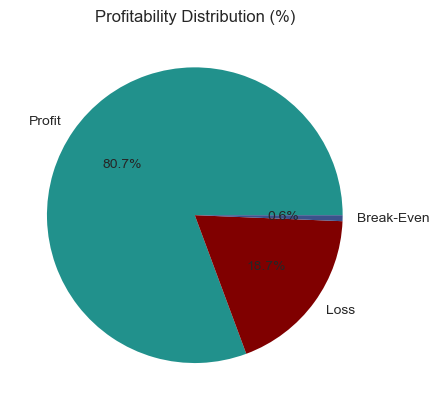

In [27]:
# visualization of profitability distribution
profit_counts = df['profitability_flag'].value_counts(normalize = True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors = [accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [51]:
le3 = 1000
le6 = 1000000
le3 = le3
le6 = le6
def format_func(value):
    if value >= le6:
        return f'{value/le6:.1f}M $'
    elif value >= le3:
        return f'{value/le3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df = df[df['delay'] > 0]
metrics = {}
metrics['total order'] = len(df)
metrics['late deliveries'] = len(delayed_df)
metrics['90% delay(days)'] = delayed_df['delay'].quantile(0.90)
metrics['on time delivery%'] = (1 - (metrics['late deliveries']) / metrics['total order']) * 100
metrics['late delivery%'] = (metrics['late deliveries']) / metrics['total order'] * 100
metrics['total profit'] = format_func(df.loc[df['order_profit_per_order'] > 0, 'order_profit_per_order'].sum())
metrics ['total loss due to delay'] = format_func(df.loc[df['delay'] > 0, 'order_profit_per_order'].sum())

print('\n-------Business KPIs--------\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")




-------Business KPIs--------

total order: 172765
late deliveries: 94523
90% delay(days): 3.00
on time delivery%: 45.29
late delivery%: 54.71
total profit: 7.5M $
total loss due to delay: 2.1M $


# Profitability vs Delivery time analysis

In [29]:
profit_metrics = (
    df.groupby('delay') ['order_profit_per_order']
    .agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        order_count = 'count'
    )
    .reset_index()
)

In [30]:
profit_metrics

,delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [31]:
delay_distribution = (
    df['delay']
    .value_counts(normalize = True)
    .sort_index()* 100
).reset_index()

In [32]:
delay_distribution

,delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Days


,delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,delay_days,percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


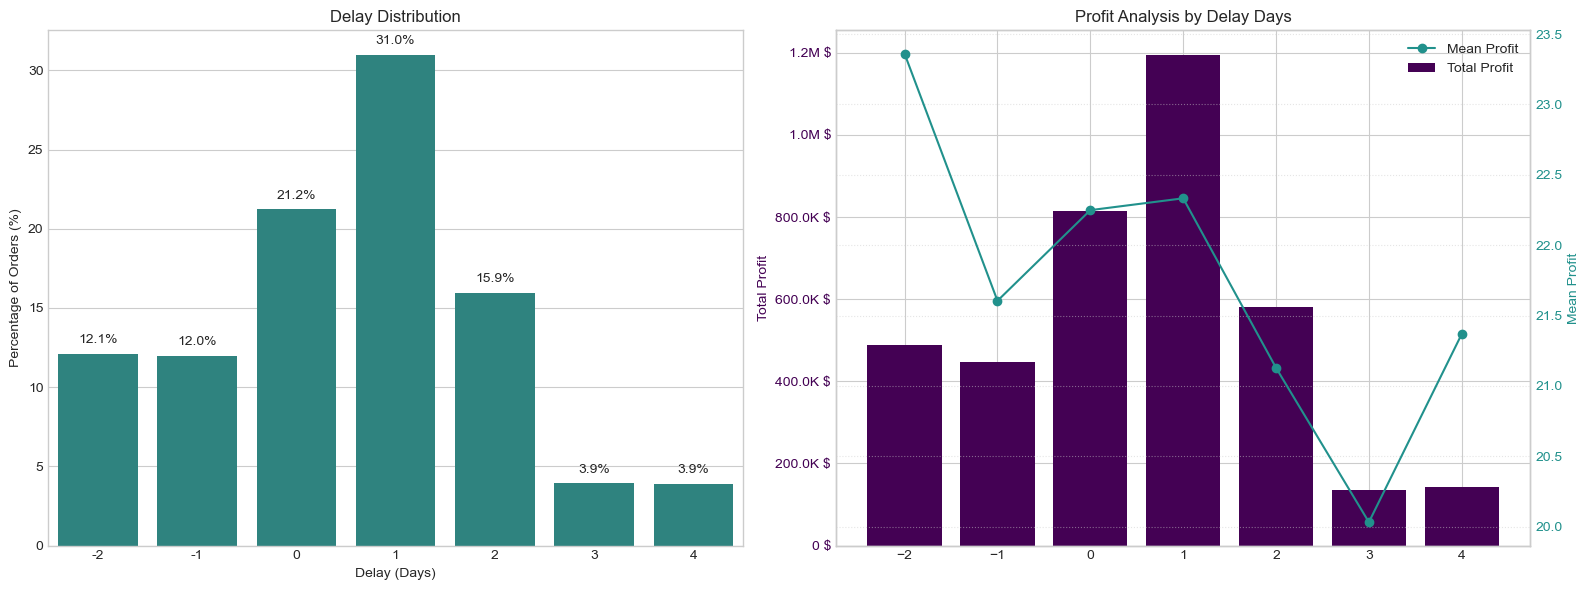

In [33]:
delay_distribution.columns = ['delay_days', 'percentage']

print("\nProfit Metrics by Delay Days")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(
    x='delay_days',
    y='percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (Days)')
ax1.set_ylabel('Percentage of Orders (%)')

# Percentage labels on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color=primary_color)

ax2.bar(
    profit_metrics['delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label="Total Profit"
)

ax2.tick_params(axis='y', labelcolor=primary_color)

# Secondary axis
ax3 = ax2.twinx()

ax3.set_xlabel('Delay Days')
ax3.set_ylabel('Mean Profit', color=accent_color)

ax3.plot(
    profit_metrics['delay'],
    profit_metrics['mean_profit'],
    marker='o',
    color=accent_color,
    label='Mean Profit'
)

ax3.tick_params(axis='y', labelcolor=accent_color)

# Format currency axis
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(format_func)
)

ax3.set_title("Profit Analysis by Delay Days")

# Combined legend
lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax3.legend(
    lines + lines2,
    labels + labels2,
    loc='upper right'
)

ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Bottleneck Detection

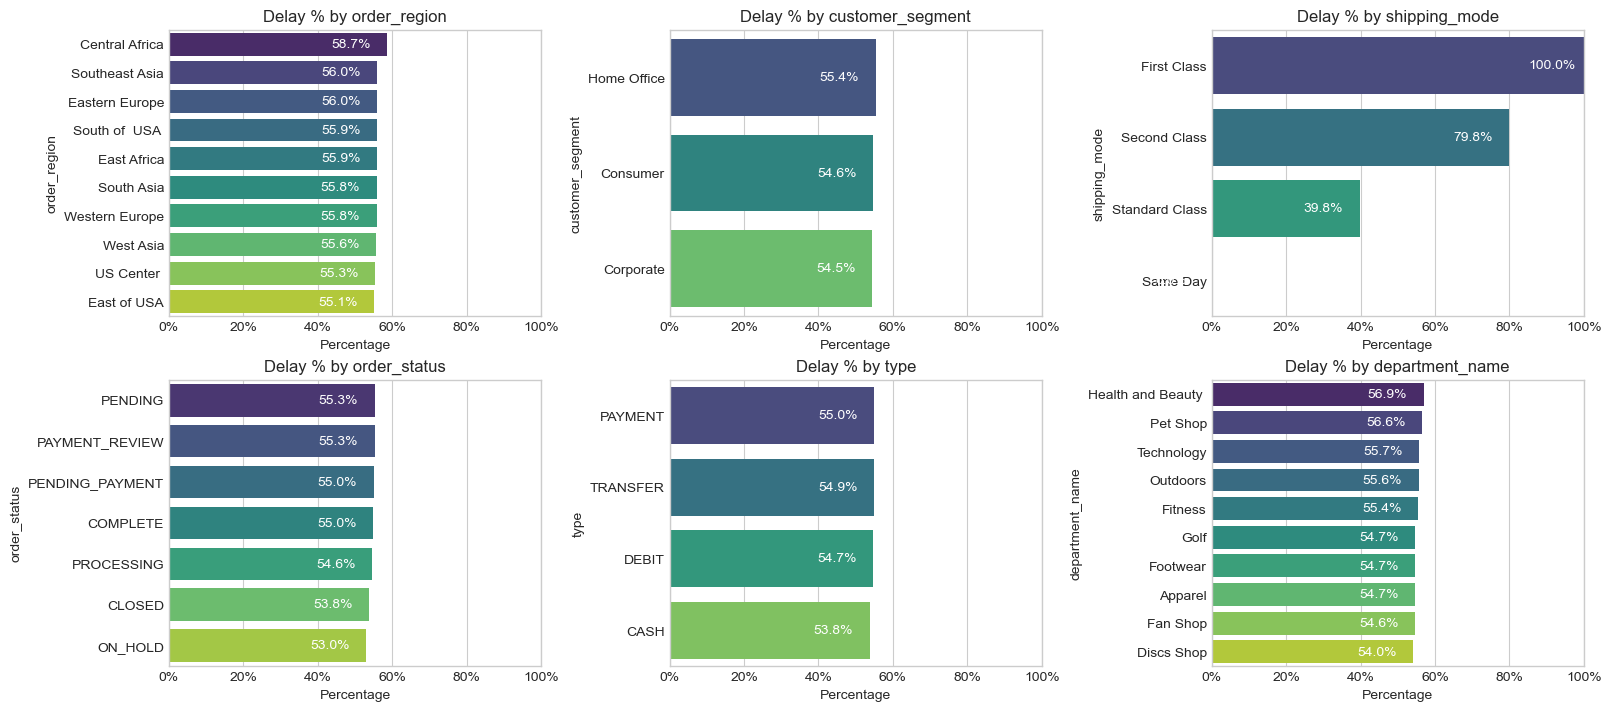

In [34]:
import matplotlib.ticker as mtick

def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders = ('delay', 'count'),
        late_orders = ('is_delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct']= cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending = False).head(10)
    return cat_df

categories = ['order_region', 'customer_segment', 'shipping_mode', 'order_status', 'type', 'department_name']

fig, axes = plt.subplots(2, 3, figsize = (16 , 7), constrained_layout = True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data = cat_df,
        x = 'delay_pct',
        y = category,
        ax = ax,
        palette = 'viridis'
    )
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('Percentage')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va = 'center', fontsize = 10, color = 'white')
plt.show()
    

# Root Cause Analysis


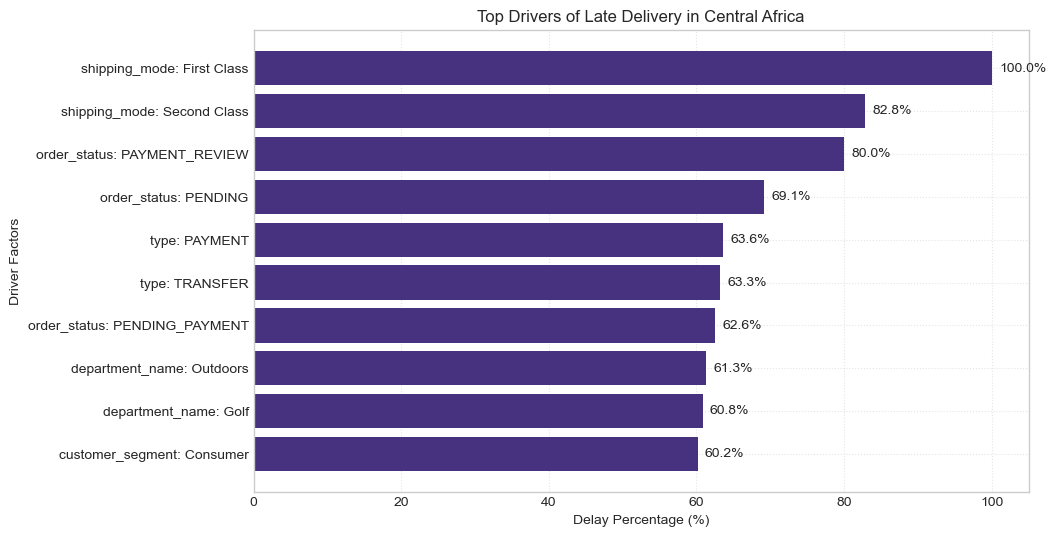

In [54]:
def top_drivers_for_region(region):
    df_region = df[df['order_region'] == region].copy()

    drivers = ['shipping_mode', 'customer_segment','department_name', 'type', 'order_status']

    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('delay', 'count'),
                late_orders=('is_delayed', 'sum'),
                avg_delay=('delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + ": " + temp[factor].astype(str)

        all_factors.append(temp[['Driver', 'Factor_Level','delay_pct', 'avg_delay', 'total_orders']])

    final_df = pd.concat(all_factors, ignore_index=True)

    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    plt.figure(figsize=(10, 6))

    bars = plt.barh(
        top_factors['Factor_Level'],
        top_factors['delay_pct']
    )
    plt.xlabel('Delay Percentage (%)')
    plt.ylabel('Driver Factors')
    plt.title(f"Top Drivers of Late Delivery in {region}")

    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 1,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            va='center'
        )

    plt.show()


top_drivers_for_region('Central Africa')

# Time-Based Analysis

In [36]:
# Delay % by month, Day of week, Hour

delay_by_month = (
    df.groupby('order_month')['is_delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['is_delayed'] * 100

delay_by_day= (
    df.groupby('order_day')['is_delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['is_delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['is_delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['is_delayed'] * 100



In [37]:
delay_by_month

,order_month,is_delayed,delay_pct
0,1,0.542542,54.254150
1,2,0.546046,54.604550
2,3,0.548094,54.809390
3,4,0.545042,54.504230
4,5,0.549980,54.998022
5,6,0.547645,54.764535
6,7,0.537310,53.731048
7,8,0.553871,55.387128
8,9,0.553885,55.388454
9,10,0.540970,54.097044


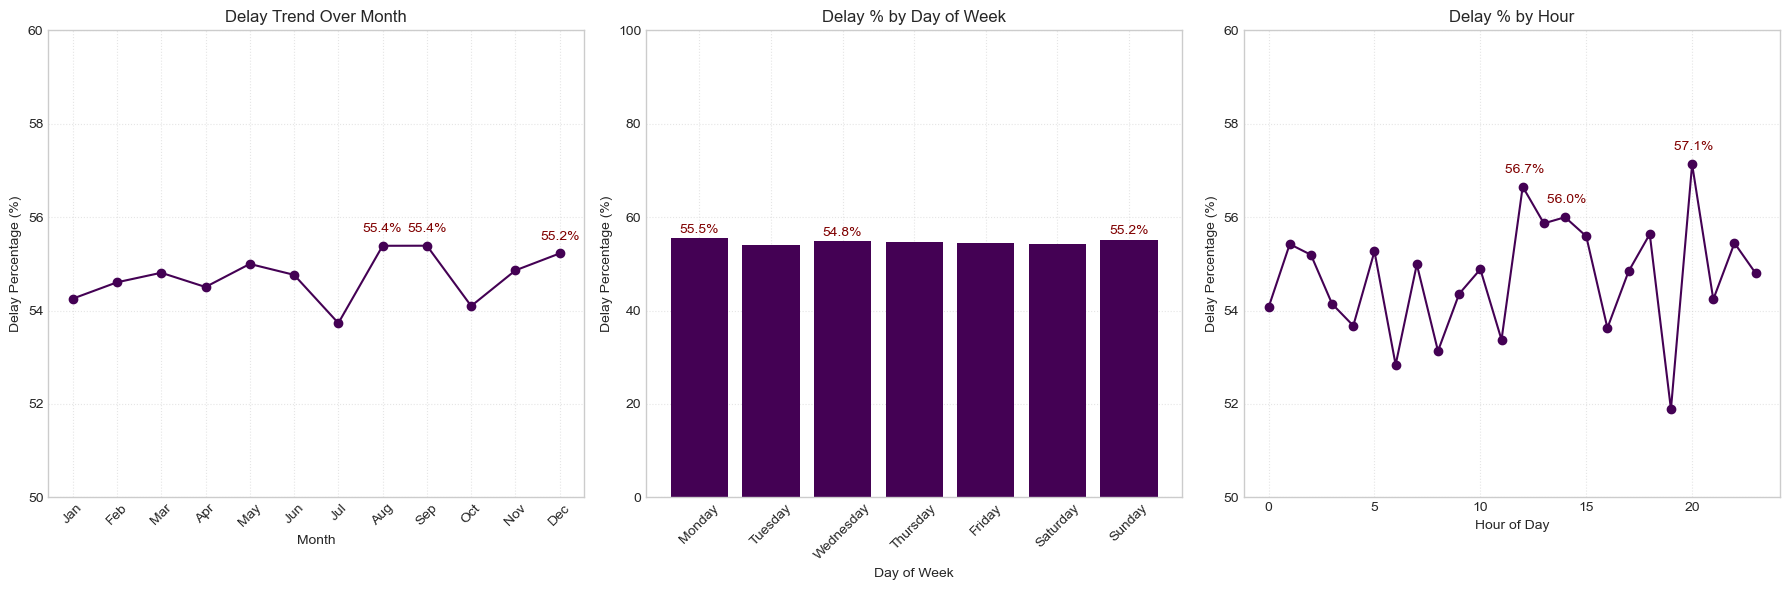

In [122]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

#Subplot 1: Delay Trend Over Month

ax1.plot(delay_by_month ['order_month'], delay_by_month ['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks (range (1,13))
ax1.set_ylim(50, 60)
ax1.set_xticklabels (['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay Trend Over Month")
ax1.grid(True, linestyle = ':', alpha = 0.5)

# Annotate top 3 highest

top3_month = delay_by_month.nlargest (3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']), 
    textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color = danger_color)

# Subplot 2: Delay by Day of Week

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd. Categorical(delay_by_day['order_day'], categories = day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')
ax2.set_ylim(0, 100)
ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels (delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

#Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height+ 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color= danger_color)

#Subplot 3: Delay by Hour
ax3.plot(delay_by_hour ['order_hour'], delay_by_hour ['delay_pct'], marker='o', color= primary_color)
ax3.set_ylim(50, 60)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

#Annotate top 3 highest

top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f" {row ['delay_pct']:.1f}%", (row['order_hour'], row ['delay_pct']),
                textcoords= 'offset points', xytext=(0,10), ha='center', fontsize=10, color=danger_color)
plt.tight_layout()
plt.show()

# Machine Learning Modeling

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [40]:
X = df[['type','days_for_shipment_(scheduled)','category_name','customer_segment','department_name','order_region','shipping_mode','order_month','order_hour']]
y = df['late_delivery_risk']

In [45]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('categorical coolumns:', cat_cols)

#Frequency encoding (low-dimension and robust for high-cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize = True)
    X[f'{col}_freq'] = X[col].map(freq)

#Keep numeric columns + new enncoded feature, drop original categories string categories
X_encoded = X.drop(columns = cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)

#use encoded feature for modeling
X = X_encoded

#train/test split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
) 

categorical coolumns: ['type', 'category_name', 'customer_segment', 'department_name', 'order_region', 'shipping_mode']
Shape after freq+target encoding: (172765, 9)


In [46]:
X_encoded

,days_for_shipment_(scheduled),order_month,order_hour,type_freq,category_name_freq,customer_segment_freq,department_name_freq,order_region_freq,shipping_mode_freq
0,4,1,22,0.401094,0.001945,0.517582,0.013741,0.052881,0.597071
1,4,1,12,0.243851,0.001945,0.517582,0.013741,0.043151,0.597071
2,4,1,12,0.113542,0.001945,0.517582,0.013741,0.043151,0.597071
3,4,1,11,0.401094,0.001945,0.178375,0.013741,0.056337,0.597071
4,4,1,11,0.241513,0.001945,0.304043,0.013741,0.056337,0.597071
...,...,...,...,...,...,...,...,...,...
180514,4,1,3,0.113542,0.096055,0.178375,0.370636,0.040361,0.597071
180515,2,1,1,0.401094,0.096055,0.304043,0.370636,0.040361,0.195676
180516,4,1,21,0.243851,0.096055,0.304043,0.370636,0.056337,0.597071
180517,4,1,20,0.241513,0.096055,0.517582,0.370636,0.056337,0.597071


In [47]:
y.value_counts()

late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

In [123]:
#Balancing the training data using SMOTE
print('Before balancing (train):', Counter(y_train))

smote = SMOTE(random_state = 42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('After balancing (train):', Counter(y_train_bal))

Before balancing (train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{'='*40}")
    print(f"{model_name}")
    print(f"{'='*40}")

    print('Accuracy :', round(accuracy_score(y_true, y_pred), 4))
    print('Precision:', round(precision_score(y_true, y_pred), 4))
    print('Recall   :', round(recall_score(y_true, y_pred), 4))
    print('F1 Score :', round(f1_score(y_true, y_pred), 4))

    print('\nConfusion Matrix:')
    print(confusion_matrix(y_true, y_pred))

    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred))

In [59]:
# Fit the random forest model on balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

# Predictions
y_pred_rf_balanced = rf_model_balanced.predict(X_test)

# Evaluation
evaluate_model(y_test, y_pred_rf_balanced, 'Random Forest Classifier')


Random Forest Classifier
Accuracy : 0.7375
Precision: 0.7852
Recall   : 0.7458
F1 Score : 0.765

Confusion Matrix:
[[10720  4038]
 [ 5032 14763]]

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.73      0.70     14758
           1       0.79      0.75      0.77     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.74      0.73     34553
weighted avg       0.74      0.74      0.74     34553

